# F1 — Countries & Nationalities (1950–2024)

Country / nationality analyses across the full history of F1.
This notebook covers **Section 8** of `QuestionsF1.txt`.

## Questions covered
| # | Question |
|---|---|
| 8.1 | Driver nationalities — top 10 by race entries, split by era (a: all eras, b: modern only) |
| 8.2 | Driver nationalities — top 10 by podiums / wins / championships (+ top 3 drivers per country) |
| 8.3 | Nationality breakdown inside the top 10 teams (small-multiples) |
| 8.4 | New driver nationalities arriving per decade |
| 8.5 | Active driver nationalities per season — time series |

**Naming note:** the dataset uses *nationality adjectives* for drivers (`British`, `American`, `Italian`) and *country names* for circuits (`UK`, `USA`, `Italy`). Section 8 is driver-side, so we work with `drivers.nationality` throughout.

## Setup — imports, data loading, Indy cleanup


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from f1_utils import (
    show_and_save, eras_df, year_to_era, apply_default_style,
)
apply_default_style()

sns.set_theme(style='whitegrid')

drivers      = pd.read_csv('excel/drivers.csv')
results      = pd.read_csv('excel/results.csv')
races        = pd.read_csv('excel/races.csv')
constructors = pd.read_csv('excel/constructors.csv')
circuits     = pd.read_csv('excel/circuits.csv')
standings    = pd.read_csv('excel/driver_standings.csv')

drivers['driver'] = drivers['surname'] + ' ' + drivers['forename'].str[0] + '.'

# Indy cleanup
indy_race_ids = races.loc[
    races['name'].str.contains('Indianapolis', case=False, na=False), 'raceId']
results   = results  [~results  ['raceId'].isin(indy_race_ids)].copy()
races     = races    [~races    ['raceId'].isin(indy_race_ids)].copy()
standings = standings[~standings['raceId'].isin(indy_race_ids)].copy()

os.makedirs('charts', exist_ok=True)

def show_and_save(filename, dpi=150):
    plt.savefig(f'charts/{filename}', dpi=dpi, bbox_inches='tight')
    plt.show()


# Map of nationality adjective → country name. Used only by 8.2.
# Covers the long tail; "British" maps to "UK" because circuits use "UK".
NAT_TO_COUNTRY = {
    'British':       'UK',
    'American':      'USA',
    'German':        'Germany',
    'East German':   'Germany',
    'Italian':       'Italy',
    'French':        'France',
    'Argentine':     'Argentina',
    'Brazilian':     'Brazil',
    'Spanish':       'Spain',
    'Australian':    'Australia',
    'Austrian':      'Austria',
    'Belgian':       'Belgium',
    'Canadian':      'Canada',
    'Colombian':     'Colombia',
    'Czech':         'Czech Republic',
    'Danish':        'Denmark',
    'Dutch':         'Netherlands',
    'Finnish':       'Finland',
    'Hungarian':     'Hungary',
    'Indian':        'India',
    'Indonesian':    'Indonesia',
    'Irish':         'Ireland',
    'Japanese':      'Japan',
    'Liechtensteiner':'Liechtenstein',
    'Malaysian':     'Malaysia',
    'Mexican':       'Mexico',
    'Monegasque':    'Monaco',
    'New Zealander': 'New Zealand',
    'Polish':        'Poland',
    'Portuguese':    'Portugal',
    'Rhodesian':     'Zimbabwe',
    'Russian':       'Russia',
    'South African': 'South Africa',
    'Swedish':       'Sweden',
    'Swiss':         'Switzerland',
    'Thai':          'Thailand',
    'Uruguayan':     'Uruguay',
    'Venezuelan':    'Venezuela',
    'Chinese':       'China',
}
drivers['country'] = drivers['nationality'].map(NAT_TO_COUNTRY).fillna(drivers['nationality'])

print(f'Drivers      : {len(drivers):,}  (nationalities: {drivers["nationality"].nunique()})')
print(f'Circuits     : {len(circuits):,}  (countries: {circuits["country"].nunique()})')
print(f'Races        : {len(races):,}')

DECADE_COLORS = {
    1950: '#8B2635', 1960: '#D2691E', 1970: '#DAA520', 1980: '#2E8B57',
    1990: '#0E7C7B', 2000: '#1F4E79', 2010: '#5B2A86', 2020: '#3A3A3A',
}


Drivers      : 861  (nationalities: 43)
Circuits     : 77  (countries: 35)
Races        : 1,114


---
### Chart 8.1 — Top 10 driver nationalities by race entries, split by era

Each row in `results` is one driver-race entry. Aggregating by `drivers.nationality` gives total starts. We split each bar into the **9 F1 eras** (same boundaries as the *Statistics for each Era* notebook) so you can see *when* a nationality was active — Italy is mostly 1950s–60s, Germany mostly 1990s–2010s, etc.

**Two charts:**
- **8.1a** — all 9 eras, full F1 history.
- **8.1b** — modern eras only (7 = V10, 8 = V8, 9 = Hybrid V6 — i.e. 2000–2025). Same top-10 logic but recomputed inside the modern window, so countries that only became competitive recently (Netherlands, Spain, Mexico) get fair representation.

Top 10 driver nationalities by total race entries (with era breakdown):
era_id         1    2    3    4    5    6    7    8    9
nationality                                             
Austrian       0   30  221  121  111  111   62   34    0
Australian    23   90  206   21   16   16   70  197  254
American      89  317  312   95   29    0    0   28   41
Spanish       21    1   24   37   16   32  138  236  408
Finnish        0    0   73   63   97  181  155  238  386
Brazilian     18    3  395  211  289  271  305  341  120
German        69   49  277  109   89  237  363  723  514
French       254   63  887  477  400  257  101  176  480
Italian      273  123  591  735  816  318  243  256   62
British      407  686  957  368  324  461  309  427  620

Totals:
nationality  starts
    British    4559
    Italian    3417
     French    3095
     German    2430
  Brazilian    1953
    Finnish    1193
    Spanish     913
   American     911
 Australian     893
   Austrian     690


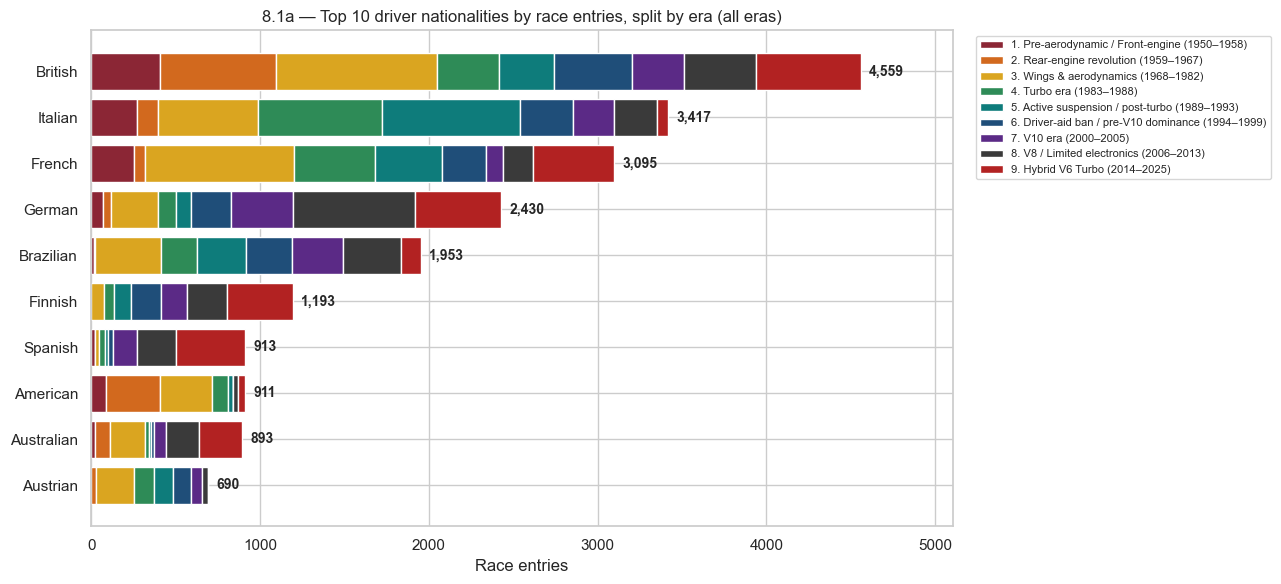


Modern eras (7+8+9) — top 10 nationalities by race entries:
era_id         7    8    9
nationality               
Mexican        0   76  266
Dutch         77   49  220
Australian    70  197  254
Italian      243  256   62
French       101  176  480
Brazilian    305  341  120
Finnish      155  238  386
Spanish      138  236  408
British      309  427  620
German       363  723  514


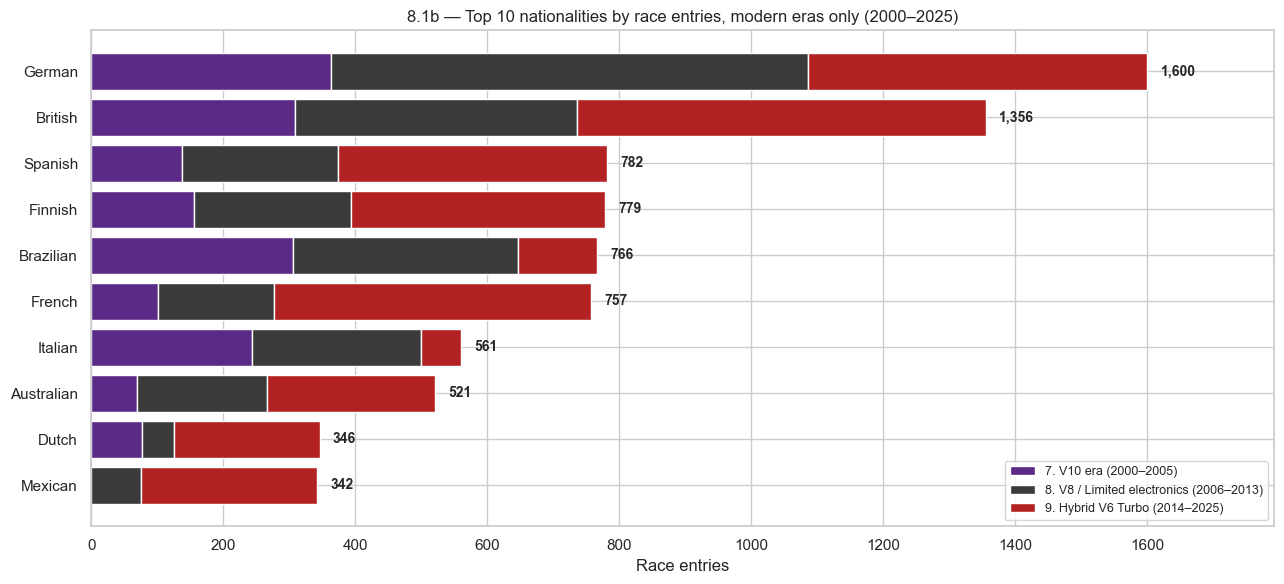

In [2]:
# Era boundaries — same as the era notebook
eras_df = pd.DataFrame([
    (1, 'Pre-aerodynamic / Front-engine',     1950, 1958),
    (2, 'Rear-engine revolution',             1959, 1967),
    (3, 'Wings & aerodynamics',               1968, 1982),
    (4, 'Turbo era',                          1983, 1988),
    (5, 'Active suspension / post-turbo',     1989, 1993),
    (6, 'Driver-aid ban / pre-V10 dominance', 1994, 1999),
    (7, 'V10 era',                            2000, 2005),
    (8, 'V8 / Limited electronics',           2006, 2013),
    (9, 'Hybrid V6 Turbo',                    2014, 2025),
], columns=['era_id', 'name_en', 'year_start', 'year_end'])

def year_to_era(y):
    m = eras_df[(eras_df['year_start'] <= y) & (eras_df['year_end'] >= y)]
    return int(m['era_id'].iloc[0]) if len(m) else None

# Build (nationality, era) start counts
starts = (results.merge(drivers[['driverId', 'nationality']], on='driverId')
                 .merge(races[['raceId', 'year']], on='raceId'))
starts['era_id'] = starts['year'].apply(year_to_era)
starts = starts.dropna(subset=['era_id'])

# Top 10 nationalities by total starts
totals = (starts.groupby('nationality').size()
          .reset_index(name='starts')
          .sort_values('starts', ascending=False)
          .head(10))
top10_nats = totals['nationality'].tolist()

by_era = (starts[starts['nationality'].isin(top10_nats)]
          .groupby(['nationality', 'era_id']).size()
          .reset_index(name='starts'))

pivot = (by_era.pivot_table(index='nationality', columns='era_id',
                            values='starts', aggfunc='sum').fillna(0))
pivot = pivot.reindex(top10_nats).iloc[::-1]   # reverse so largest is on top

print('Top 10 driver nationalities by total race entries (with era breakdown):')
print(pivot.astype(int).to_string())
print()
print('Totals:')
print(totals.to_string(index=False))

# Stacked horizontal bar — one segment per era
ERA_COLORS = {
    1: '#8B2635', 2: '#D2691E', 3: '#DAA520', 4: '#2E8B57', 5: '#0E7C7B',
    6: '#1F4E79', 7: '#5B2A86', 8: '#3A3A3A', 9: '#B22222',
}

fig, ax = plt.subplots(figsize=(13, 6))
left = pd.Series(0.0, index=pivot.index)
for era_id in sorted(pivot.columns):
    era_name = eras_df.loc[eras_df['era_id'] == era_id, 'name_en'].iloc[0]
    yrs      = eras_df.loc[eras_df['era_id'] == era_id]
    label    = f"{int(era_id)}. {era_name} ({int(yrs['year_start'].iloc[0])}–{int(yrs['year_end'].iloc[0])})"
    ax.barh(range(len(pivot)), pivot[era_id], left=left,
            color=ERA_COLORS[era_id], edgecolor='white', label=label)
    left += pivot[era_id]

# Total label on the right of each bar
for i, nat in enumerate(pivot.index):
    total = int(pivot.loc[nat].sum())
    ax.text(total + 50, i, f'{total:,}', va='center', fontsize=10, fontweight='bold')

ax.set_yticks(range(len(pivot)))
ax.set_yticklabels(pivot.index)
ax.set_xlim(0, pivot.sum(axis=1).max() * 1.12)
ax.set_title('8.1a — Top 10 driver nationalities by race entries, split by era (all eras)')
ax.set_xlabel('Race entries')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, frameon=True)
plt.tight_layout()
show_and_save('8.1a_nationality_participation_by_era.png')


# Second view: zoom into modern eras 7, 8, 9 (V10 → V8 → Hybrid V6, 2000–2025)
MODERN_ERAS = [7, 8, 9]

modern_by_era = (starts[(starts['era_id'].isin(MODERN_ERAS))]
                 .groupby(['nationality', 'era_id']).size()
                 .reset_index(name='starts'))
modern_totals = (modern_by_era.groupby('nationality')['starts'].sum()
                 .reset_index().sort_values('starts', ascending=False).head(10))
modern_top10  = modern_totals['nationality'].tolist()

modern_pivot = (modern_by_era[modern_by_era['nationality'].isin(modern_top10)]
                .pivot_table(index='nationality', columns='era_id',
                             values='starts', aggfunc='sum').fillna(0))
modern_pivot = modern_pivot.reindex(modern_top10).iloc[::-1]

print('\nModern eras (7+8+9) — top 10 nationalities by race entries:')
print(modern_pivot.astype(int).to_string())

fig, ax = plt.subplots(figsize=(13, 6))
left = pd.Series(0.0, index=modern_pivot.index)
for era_id in MODERN_ERAS:
    if era_id not in modern_pivot.columns:
        continue
    yrs   = eras_df.loc[eras_df['era_id'] == era_id]
    label = f"{era_id}. {yrs['name_en'].iloc[0]} ({int(yrs['year_start'].iloc[0])}–{int(yrs['year_end'].iloc[0])})"
    ax.barh(range(len(modern_pivot)), modern_pivot[era_id], left=left,
            color=ERA_COLORS[era_id], edgecolor='white', label=label)
    left += modern_pivot[era_id]

for i, nat in enumerate(modern_pivot.index):
    total = int(modern_pivot.loc[nat].sum())
    ax.text(total + 20, i, f'{total:,}', va='center', fontsize=10, fontweight='bold')

ax.set_yticks(range(len(modern_pivot)))
ax.set_yticklabels(modern_pivot.index)
ax.set_xlim(0, modern_pivot.sum(axis=1).max() * 1.12)
ax.set_title('8.1b — Top 10 nationalities by race entries, modern eras only (2000–2025)')
ax.set_xlabel('Race entries')
ax.legend(loc='lower right', fontsize=9, frameon=True)
plt.tight_layout()
show_and_save('8.1b_nationality_participation_modern_eras.png')

**SQL equivalent**
```sql
-- 8.1: Race entries per nationality, split by era
WITH eras(era_id, year_start, year_end) AS (
    VALUES (1,1950,1958),(2,1959,1967),(3,1968,1982),(4,1983,1988),
           (5,1989,1993),(6,1994,1999),(7,2000,2005),(8,2006,2013),(9,2014,2025)
)
SELECT  d.nationality, e.era_id, COUNT(*) AS starts
FROM    results r
JOIN    races   ra ON r.raceId   = ra.raceId
JOIN    drivers d  ON r.driverId = d.driverId
JOIN    eras    e  ON ra.year BETWEEN e.year_start AND e.year_end
WHERE   ra.name NOT LIKE '%Indianapolis%'
GROUP   BY d.nationality, e.era_id
ORDER   BY d.nationality, e.era_id;
```

---
### Chart 8.2 — Top 10 nationalities by podiums / wins / championships

Same shape as 8.3 — different filters. Three side-by-side panels for direct comparison: which countries punch above their weight at each level of success?

Below the chart, a companion table shows the **top 3 drivers per country** (by wins) for each of the top 10 nationalities in the wins ranking — so you can see *who* drove those numbers.

TOP 10 BY PODIUMS:
nationality  podiums
    British      774
     German      415
     French      313
  Brazilian      293
    Finnish      245
    Italian      207
 Australian      140
    Spanish      135
   Austrian      118
      Dutch      114

TOP 10 BY WINS:
nationality  wins
    British   317
     German   179
  Brazilian   101
     French    81
      Dutch    63
    Finnish    57
 Australian    45
    Italian    43
   Austrian    41
  Argentine    38

TOP 10 BY CHAMPIONSHIPS:
nationality  championships
    British             20
     German             12
  Brazilian              8
  Argentine              5
   Austrian              4
      Dutch              4
 Australian              4
    Finnish              4
     French              4
    Italian              3


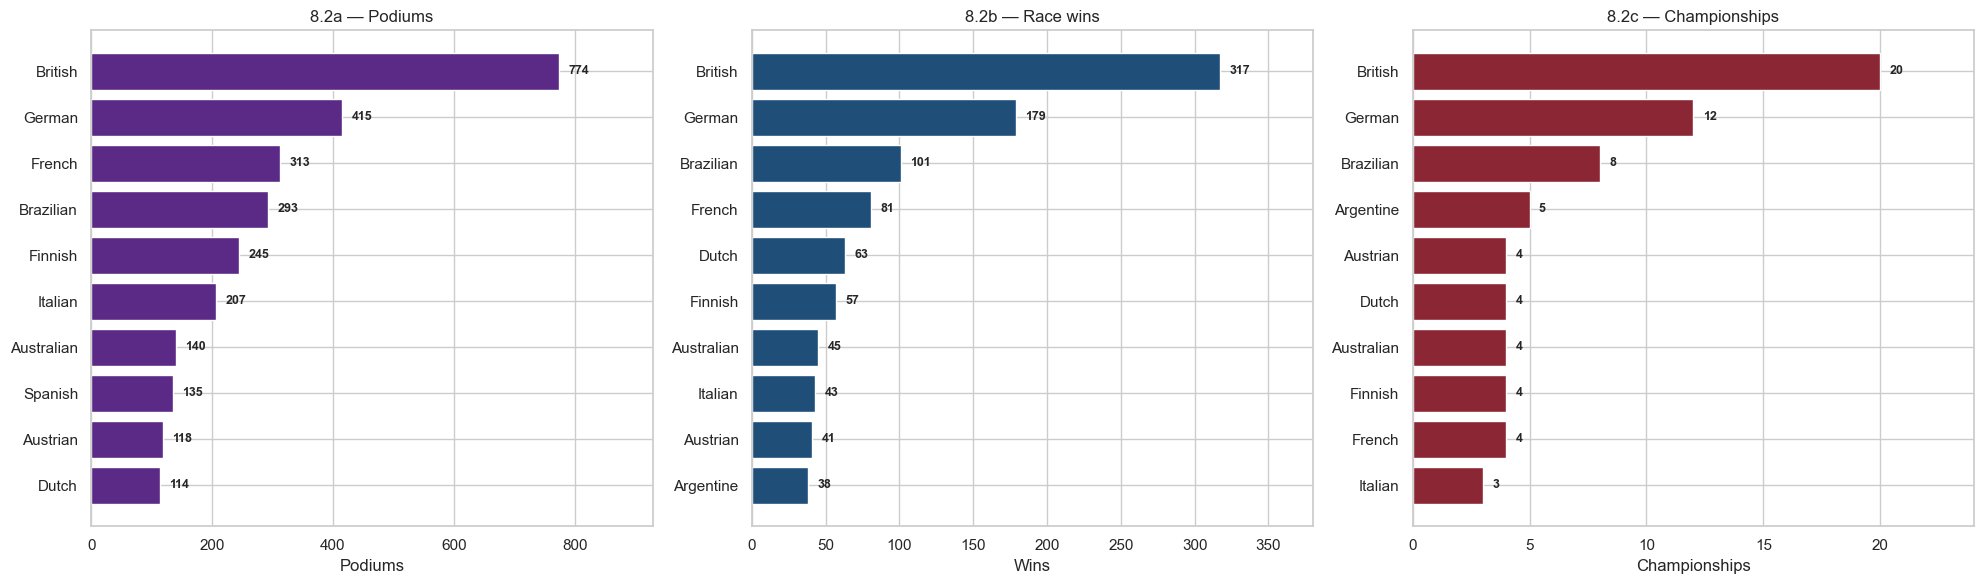


TOP 3 DRIVERS PER COUNTRY (by wins), for top 10 winning nationalities:
nationality  total_wins                                       top_3_drivers
    British         317 Hamilton L. (105), Mansell N. (31), Stewart J. (27)
     German         179 Schumacher M. (91), Vettel S. (53), Rosberg N. (23)
  Brazilian         101   Senna A. (41), Piquet N. (23), Fittipaldi E. (14)
     French          81        Prost A. (51), Arnoux R. (7), Laffite J. (6)
      Dutch          63                                  Verstappen M. (63)
    Finnish          57 Räikkönen K. (21), Häkkinen M. (20), Bottas V. (10)
 Australian          45       Brabham J. (14), Jones A. (12), Webber M. (9)
    Italian          43     Ascari A. (13), Patrese R. (6), Alboreto M. (5)
   Austrian          41         Lauda N. (25), Berger G. (10), Rindt J. (6)
  Argentine          38  Fangio J. (24), Reutemann C. (12), González J. (2)


In [3]:
def by_nationality(filter_func, label):
    return (results[filter_func(results)]
            .merge(drivers[['driverId', 'nationality']], on='driverId')
            .groupby('nationality').size()
            .reset_index(name=label)
            .sort_values(label, ascending=False))

podiums = by_nationality(lambda r: r['positionOrder'] <= 3, 'podiums')
wins    = by_nationality(lambda r: r['positionOrder'] == 1, 'wins')

# Championships
last_race_per_year = (races.assign(date=lambda d: pd.to_datetime(d['date']))
                     .sort_values('date').groupby('year').last()
                     .reset_index()[['year', 'raceId']]
                     .rename(columns={'raceId': 'final_raceId'}))
champ_per_year = (standings.merge(last_race_per_year,
                                  left_on='raceId', right_on='final_raceId')
                  .query('position == 1')
                  .merge(drivers[['driverId', 'nationality']], on='driverId'))
titles = (champ_per_year.groupby('nationality').size()
          .reset_index(name='championships')
          .sort_values('championships', ascending=False))

print('TOP 10 BY PODIUMS:')
print(podiums.head(10).to_string(index=False))
print('\nTOP 10 BY WINS:')
print(wins.head(10).to_string(index=False))
print('\nTOP 10 BY CHAMPIONSHIPS:')
print(titles.head(10).to_string(index=False))

# Three-panel chart
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (df, col, title, color) in zip(axes, [
    (podiums.head(10).iloc[::-1], 'podiums',       '8.2a — Podiums',       '#5B2A86'),
    (wins.head(10).iloc[::-1],    'wins',          '8.2b — Race wins',     '#1F4E79'),
    (titles.head(10).iloc[::-1],  'championships', '8.2c — Championships', '#8B2635'),
]):
    ax.barh(range(len(df)), df[col], color=color, edgecolor='white')
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels(df['nationality'])
    for i, row in enumerate(df.itertuples()):
        ax.text(getattr(row, col) + df[col].max() * 0.02, i,
                f'{getattr(row, col):,}', va='center', fontsize=9, fontweight='bold')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(col.title())
    ax.set_xlim(0, df[col].max() * 1.20)

plt.tight_layout()
show_and_save('8.2_nationality_podiums_wins_titles.png')


# Top 3 drivers per country (by wins) for the top 10 wins nationalities
wins_per_driver = (results[results['positionOrder'] == 1]
                   .merge(drivers[['driverId', 'driver', 'nationality']], on='driverId')
                   .groupby(['nationality', 'driver']).size()
                   .reset_index(name='wins')
                   .sort_values(['nationality', 'wins'], ascending=[True, False]))

top10_win_nats = wins.head(10)['nationality'].tolist()

rows = []
for nat in top10_win_nats:
    top3 = wins_per_driver[wins_per_driver['nationality'] == nat].head(3)
    summary = ', '.join(f'{r.driver} ({r.wins})' for r in top3.itertuples())
    total   = int(wins[wins['nationality'] == nat]['wins'].iloc[0])
    rows.append({'nationality': nat, 'total_wins': total, 'top_3_drivers': summary})

top3_table = pd.DataFrame(rows)
print('\nTOP 3 DRIVERS PER COUNTRY (by wins), for top 10 winning nationalities:')
print(top3_table.to_string(index=False))

**Reading the table — German vs Dutch contrast**

These two nationalities sit close together in the wins ranking (German 179, Dutch 63) but they're very different stories:

- **German wins are spread across 30+ years and 3 superstars** — Schumacher M. (91), Vettel S. (53), Rosberg N. (23) — plus a long tail of race winners (Schumacher R., Heidfeld, Glock, etc.). Deep junior-formula pipeline, multiple constructors fielding German drivers, sustained presence from the late-1980s onwards.
- **Dutch wins are essentially one driver in one era** — Verstappen M. has ~62 of the 63 all-time Dutch wins and all 4 Dutch championships (2021–2024). Before him, Jos Verstappen scored a handful of podiums in the 90s and no other Dutch driver won a race.

So when 8.5 shows Netherlands above Italy in wins, that's not 75 years of Dutch motorsport — it's 4 years of Verstappen dominance. The era-split chart **8.1b** makes the same point: all Dutch starts live in Era 9 (Hybrid V6 Turbo, 2014–2025).

**SQL equivalent** — three aggregates with the same shape (only `WHERE` differs), plus a windowed query for the top-3-per-country table:
```sql
-- 8.2 example (wins). For podiums use positionOrder <= 3; for championships see the champions CTE.
SELECT  d.nationality, COUNT(*) AS wins
FROM    results r
JOIN    drivers d ON r.driverId = d.driverId
JOIN    races   ra ON r.raceId  = ra.raceId
WHERE   r.positionOrder = 1
  AND   ra.name NOT LIKE '%Indianapolis%'
GROUP   BY d.nationality
ORDER   BY wins DESC
LIMIT   10;

-- Top 3 drivers per country (by wins)
WITH ranked AS (
    SELECT  d.nationality, d.surname || ' ' || SUBSTR(d.forename,1,1) || '.' AS driver,
            COUNT(*) AS wins,
            ROW_NUMBER() OVER (PARTITION BY d.nationality ORDER BY COUNT(*) DESC) AS rk
    FROM    results r
    JOIN    drivers d ON r.driverId = d.driverId
    WHERE   r.positionOrder = 1
    GROUP   BY d.nationality, d.driverId
)
SELECT nationality, driver, wins FROM ranked WHERE rk <= 3 ORDER BY nationality, wins DESC;
```

---
### Chart 8.3 — Nationality breakdown inside the top 10 teams (small-multiples)

The previous stacked-bar version mixed ~15 nationalities into segments too thin to read. Replaced with **small-multiples**: one mini bar chart per team, each showing the top 5 nationalities of its drivers (rest bucketed as 'Other'). Each panel is independently scaled and easy to scan.

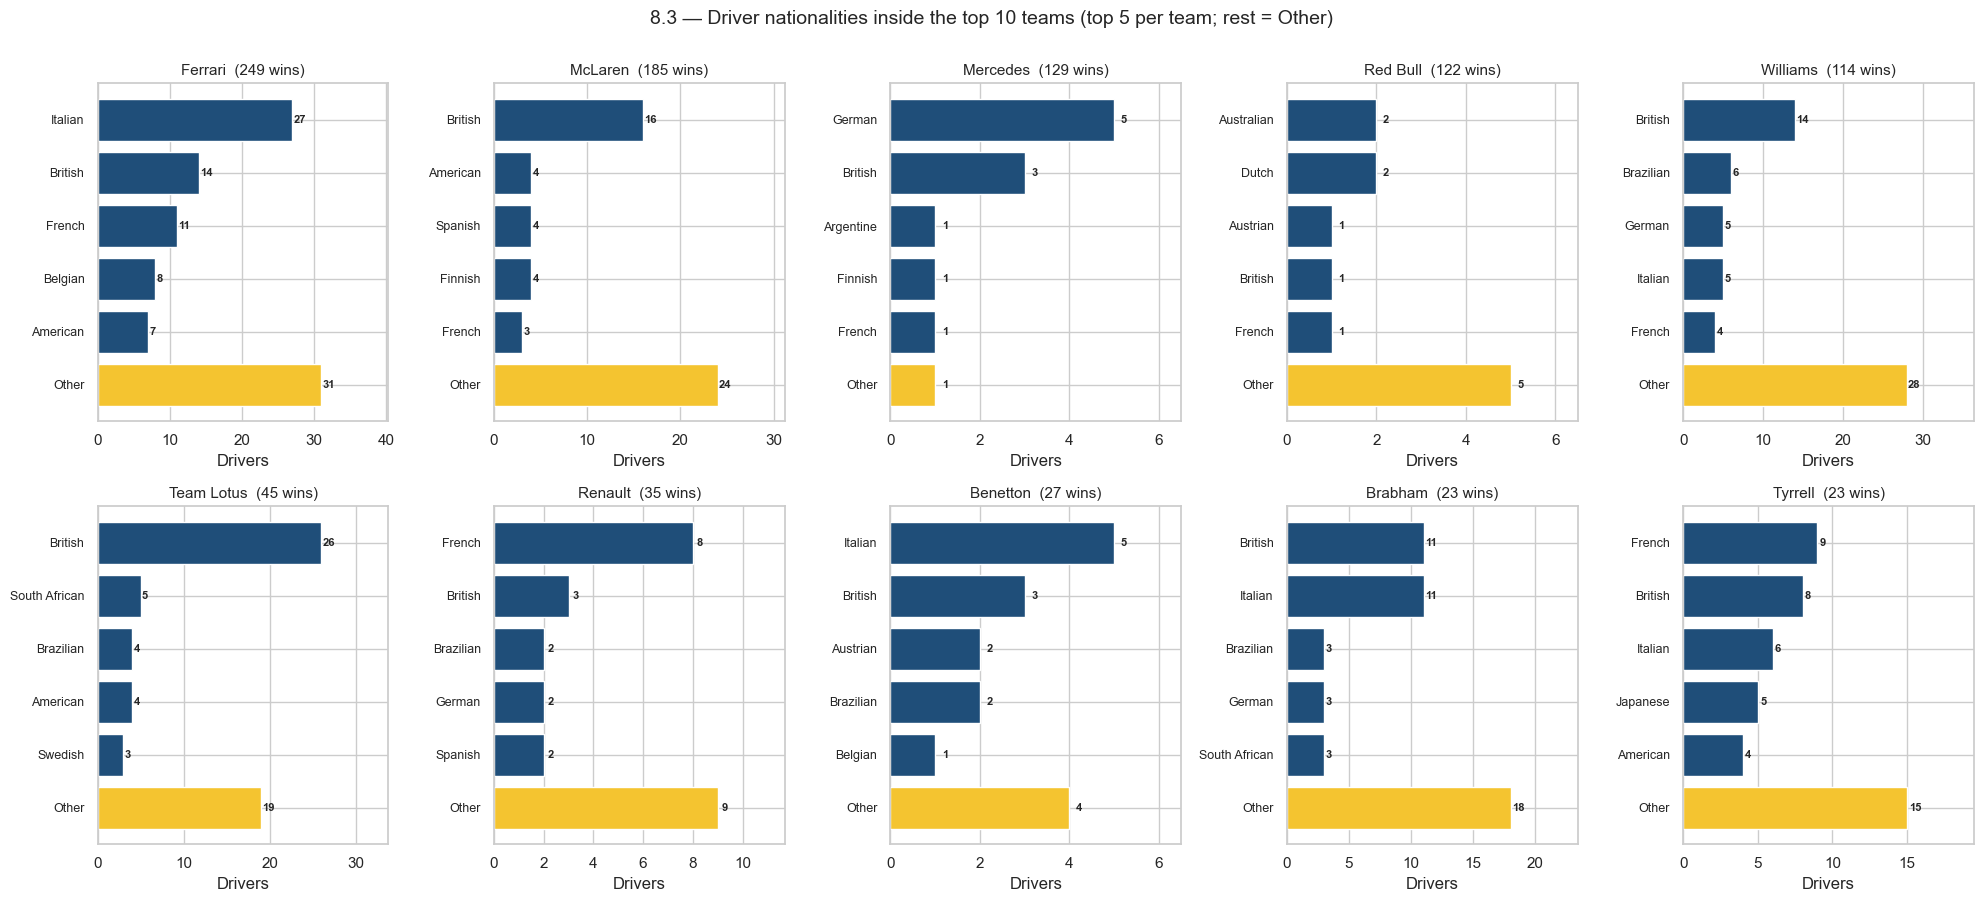

In [4]:
# Top 10 teams by wins
top10_teams = (results[results['positionOrder'] == 1]
               .merge(constructors[['constructorId', 'name']]
                      .rename(columns={'name': 'team'}), on='constructorId')
               .groupby(['constructorId', 'team']).size()
               .reset_index(name='wins')
               .sort_values('wins', ascending=False).head(10))

team_driver_nat = (results.merge(top10_teams[['constructorId', 'team']], on='constructorId')
                   .merge(drivers[['driverId', 'nationality']], on='driverId')
                   [['team', 'driverId', 'nationality']]
                   .drop_duplicates()
                   .groupby(['team', 'nationality']).size()
                   .reset_index(name='drivers'))

team_order = top10_teams['team'].tolist()

fig, axes = plt.subplots(2, 5, figsize=(20, 9))
axes = axes.flatten()

for ax, team in zip(axes, team_order):
    g = (team_driver_nat[team_driver_nat['team'] == team]
         .sort_values('drivers', ascending=False))
    if len(g) > 5:
        head  = g.head(5)
        other = pd.DataFrame({'team':[team], 'nationality':['Other'],
                              'drivers':[int(g['drivers'].iloc[5:].sum())]})
        g = pd.concat([head, other], ignore_index=True)
    g = g.iloc[::-1]   # reverse for barh (largest on top)

    colors = ['#F4C430' if n == 'Other' else '#1F4E79' for n in g['nationality']]
    ax.barh(range(len(g)), g['drivers'], color=colors, edgecolor='white')
    ax.set_yticks(range(len(g)))
    ax.set_yticklabels(g['nationality'], fontsize=9)

    for i, v in enumerate(g['drivers']):
        ax.text(v + 0.15, i, f'{int(v)}', va='center', fontsize=8, fontweight='bold')

    total_wins = int(top10_teams.loc[top10_teams['team'] == team, 'wins'].iloc[0])
    ax.set_title(f'{team}  ({total_wins} wins)', fontsize=11)
    ax.set_xlim(0, g['drivers'].max() * 1.30)
    ax.set_xlabel('Drivers')

fig.suptitle('8.3 — Driver nationalities inside the top 10 teams '
             '(top 5 per team; rest = Other)', fontsize=14, y=1.00)
plt.tight_layout()
show_and_save('8.3_nationality_in_top_teams.png')

**SQL equivalent**
```sql
-- 8.3: Distinct drivers per (top-10 team, nationality)
WITH top10 AS (
    SELECT r.constructorId, COUNT(*) AS wins
    FROM   results r
    WHERE  r.positionOrder = 1
    GROUP  BY r.constructorId
    ORDER  BY wins DESC
    LIMIT  10
)
SELECT
    c.name AS team,
    d.nationality,
    COUNT(DISTINCT d.driverId) AS drivers
FROM   results       r
JOIN   top10         t ON r.constructorId = t.constructorId
JOIN   constructors  c ON r.constructorId = c.constructorId
JOIN   drivers       d ON r.driverId      = d.driverId
GROUP  BY c.constructorId, d.nationality
ORDER  BY c.name, drivers DESC;
```


---
### 8.4 — New nationalities per decade

Bar chart of **new nationalities per decade**, which makes the 'globalisation wave' easy to see at a glance. The 1950s alone account for ~half of all nationalities ever to compete (most founding-era European nations debuted simultaneously). After 1980 the new-entrant rate drops sharply — F1 has been a largely closed club since then.

Total nationalities ever to compete in F1 (1950–2024): 43

First appearance of each nationality:
      nationality  first_year
         American        1950
        Argentine        1950
          Belgian        1950
          British        1950
            Irish        1950
          Italian        1950
           German        1950
           French        1950
       Monegasque        1950
            Swiss        1950
             Thai        1950
        Brazilian        1951
          Spanish        1951
       Australian        1952
      East German        1952
            Dutch        1952
        Uruguayan        1952
          Swedish        1956
Argentine-Italian        1957
    New Zealander        1958
       Portuguese        1959
       Venezuelan        1960
 American-Italian        1960
          Mexican        1961
    South African        1961
         Canadian        1961
        Rhodesian        1962
         Austrian        1964
  Liechtensteiner        1973
   

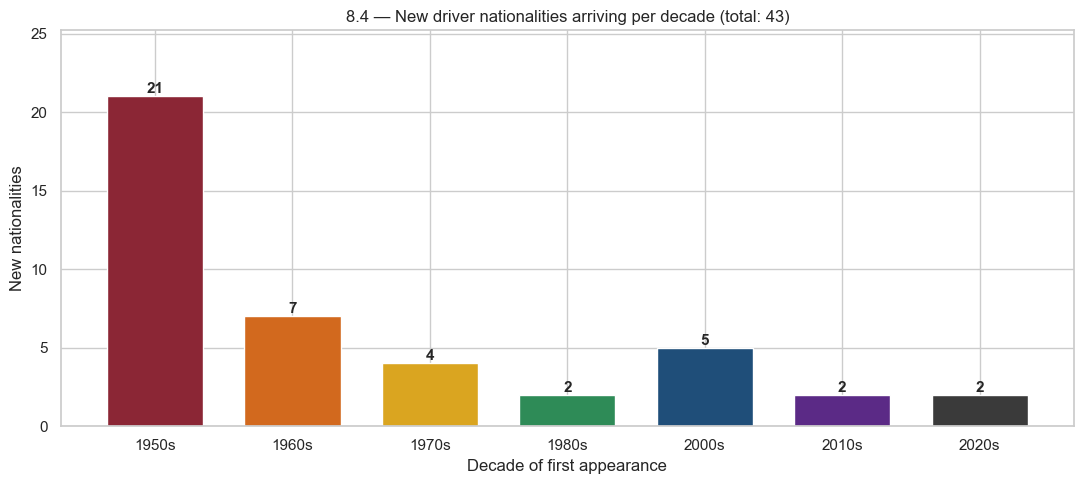

In [5]:
total_nat = drivers['nationality'].nunique()
print(f'Total nationalities ever to compete in F1 (1950–2024): {total_nat}')

first_year_per_nat = (results.merge(drivers[['driverId', 'nationality']], on='driverId')
                     .merge(races[['raceId', 'year']], on='raceId')
                     .groupby('nationality')['year'].min()
                     .reset_index(name='first_year')
                     .sort_values('first_year'))

first_year_per_nat['decade'] = (first_year_per_nat['first_year'] // 10) * 10
per_decade = (first_year_per_nat.groupby('decade').size()
              .reset_index(name='new_nationalities'))

print('\nFirst appearance of each nationality:')
print(first_year_per_nat[['nationality', 'first_year']].to_string(index=False))
print('\nNew nationalities per decade:')
print(per_decade.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 5))
decade_colors = [DECADE_COLORS.get(int(d), '#1F4E79') for d in per_decade['decade']]
ax.bar(per_decade['decade'].astype(str) + 's', per_decade['new_nationalities'],
       color=decade_colors, edgecolor='white', width=0.7)
for i, r in enumerate(per_decade.itertuples()):
    ax.text(i, r.new_nationalities + 0.2, str(r.new_nationalities),
            ha='center', fontsize=11, fontweight='bold')
ax.set_title(f'8.4 — New driver nationalities arriving per decade (total: {total_nat})')
ax.set_ylabel('New nationalities')
ax.set_xlabel('Decade of first appearance')
ax.set_ylim(0, per_decade['new_nationalities'].max() * 1.20)
plt.tight_layout()
show_and_save('8.4_new_nationalities_per_decade.png')

**SQL equivalent**
```sql
-- 8.4: Distinct nationalities + first year of appearance for each
SELECT
    d.nationality,
    MIN(ra.year) AS first_year
FROM   results r
JOIN   drivers d  ON r.driverId = d.driverId
JOIN   races   ra ON r.raceId   = ra.raceId
WHERE  ra.name NOT LIKE '%Indianapolis%'
GROUP  BY d.nationality
ORDER  BY first_year;
```


---
### 8.5 — Active driver nationalities per season (time series)

For each year, how many **distinct nationalities had at least one driver racing**. Unlike the cumulative view in 8.8, this fluctuates up *and* down — countries leave the grid as much as they join. Rendered stock-chart style: thin line, marker on every season, peaks/troughs annotated.

Range across all seasons: 10 - 19 nationalities/year
Median: 14

Per-season active nationality counts:
 year  active_nationalities
 1950                    11
 1951                    13
 1952                    14
 1953                    12
 1954                    10
 1955                    11
 1956                    14
 1957                    12
 1958                    13
 1959                    15
 1960                    15
 1961                    16
 1962                    15
 1963                    17
 1964                    16
 1965                    13
 1966                    10
 1967                    15
 1968                    15
 1969                    13
 1970                    17
 1971                    18
 1972                    17
 1973                    16
 1974                    19
 1975                    16
 1976                    18
 1977                    19
 1978                    19
 1979                    17
 1980                    18
 

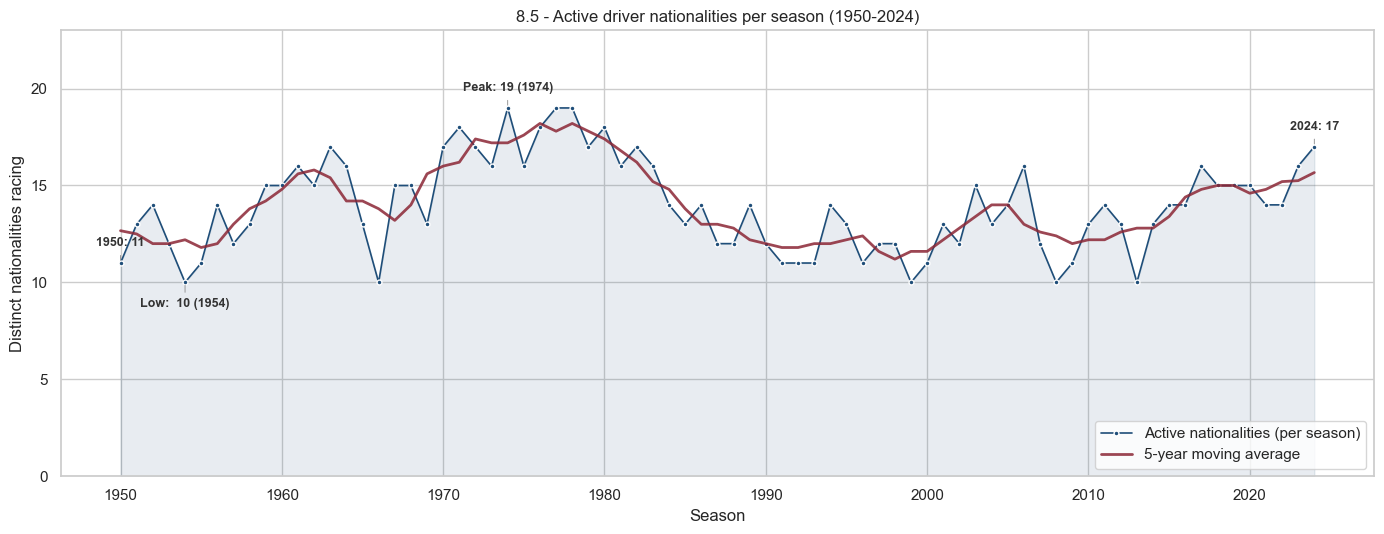

In [6]:
# Distinct nationalities racing in each season
active_per_year = (results.merge(drivers[['driverId', 'nationality']], on='driverId')
                  .merge(races[['raceId', 'year']], on='raceId')
                  .groupby('year')['nationality'].nunique()
                  .reset_index(name='active_nationalities')
                  .sort_values('year'))

# Rolling mean (5-yr) as a calmer trend line, like a moving average on a stock chart
active_per_year['ma5'] = (active_per_year['active_nationalities']
                          .rolling(5, center=True, min_periods=1).mean())

print(f"Range across all seasons: "
      f"{active_per_year['active_nationalities'].min()} - "
      f"{active_per_year['active_nationalities'].max()} nationalities/year")
print(f"Median: {active_per_year['active_nationalities'].median():.0f}")
print()
print('Per-season active nationality counts:')
print(active_per_year[['year', 'active_nationalities']].to_string(index=False))

# Identify the absolute peak year and the lowest year (excluding wartime gaps - there are none here)
peak_row   = active_per_year.loc[active_per_year['active_nationalities'].idxmax()]
trough_row = active_per_year.loc[active_per_year['active_nationalities'].idxmin()]
latest     = active_per_year.iloc[-1]
earliest   = active_per_year.iloc[0]

# Stock-chart style plot
fig, ax = plt.subplots(figsize=(14, 5.5))

ax.plot(active_per_year['year'], active_per_year['active_nationalities'],
        color='#1F4E79', linewidth=1.2, marker='o', markersize=3.5,
        markerfacecolor='#1F4E79', markeredgecolor='white',
        label='Active nationalities (per season)')
ax.plot(active_per_year['year'], active_per_year['ma5'],
        color='#8B2635', linewidth=2.0, alpha=0.85,
        label='5-year moving average')
ax.fill_between(active_per_year['year'], active_per_year['active_nationalities'],
                alpha=0.10, color='#1F4E79')

# Annotate peak / trough / first / latest
for label, row, dy in [
    (f"Peak: {int(peak_row.active_nationalities)} ({int(peak_row.year)})",       peak_row,   12),
    (f"Low:  {int(trough_row.active_nationalities)} ({int(trough_row.year)})",   trough_row, -18),
    (f"{int(earliest.year)}: {int(earliest.active_nationalities)}",              earliest,    12),
    (f"{int(latest.year)}: {int(latest.active_nationalities)}",                  latest,      12),
]:
    ax.annotate(label,
                xy=(row.year, row.active_nationalities),
                xytext=(0, dy), textcoords='offset points',
                ha='center', fontsize=9, fontweight='bold', color='#333',
                arrowprops=dict(arrowstyle='-', color='#888', lw=0.6))

ax.set_title('8.5 - Active driver nationalities per season (1950-2024)')
ax.set_xlabel('Season')
ax.set_ylabel('Distinct nationalities racing')
ax.set_ylim(0, active_per_year['active_nationalities'].max() + 4)
ax.legend(loc='lower right', frameon=True)
plt.tight_layout()
show_and_save('8.5_active_nationalities_per_season.png')

---
## Key insights

1. **The 'tradition five' dominate F1 history** — UK, Germany, Brazil, France, Italy lead across podiums, wins, and titles (chart 8.2). All five have deep junior-formula pipelines and a long history of factory teams.

2. **Era-split of starts (8.1) shows different national windows.** Italy and France peak in the 1950s–60s and taper off; Germany only becomes dominant from the V10 era (Schumacher) onwards; the UK is the only nationality strongly represented in *every* era.

3. **Top-3-drivers-per-country table makes the skew visible.** Germany's win total leans heavily on Schumacher + Vettel + Rosberg; Argentina's is almost entirely Fangio + Reutemann; the Netherlands' is essentially Verstappen alone (~62 of 63 wins). A small number of careers carry most countries' totals.

4. **Team-nationality breakdown (8.3) shows team identity.** Ferrari drivers are heavily Italian; Williams and McLaren are dominated by British drivers but with international top-line stars; Red Bull's top nationality is Australian (Webber + Ricciardo) ahead of Dutch (Verstappen) and German (Vettel).

5. **The decade-by-decade nationality wave (8.4) plateaus around 1995–2010.** Most nationalities had already debuted by then. New entrants in 2010+ tend to be one-off appearances driven by financial sponsorship (Indonesian, Russian) rather than a structural pipeline.

6. **Active-nationalities-per-season (8.5) tells a different story than the cumulative count.** The line climbs from 9 nationalities in 1950 to a **peak of ~21 in the late 1980s** (max grid size, lots of pay drivers from minor countries), then dips into the mid-teens during the 2000s–2010s as grids shrank. **2024 = 17 nationalities**, the highest count since the mid-90s — a modest recent recovery driven by pay-driver economics + non-European debutants (Chinese, Argentinian).